In [3]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 4.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 5.0 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 5.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.9 MB/s  0:00:00

   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# עיצוב כללי לגרפים שייראו מקצועיים
sns.set_theme(style="whitegrid")

# נתיב לקובץ המעובד שלנו
# שים לב: במחברת שנמצאת ב-notebooks/EDA, אנחנו צריכים לעלות שתי רמות אחורה
DATA_PATH = '../../data/processed/att_with_tiers_for_eda.csv'

print("Loading data for EDA...")
df = pd.read_csv(DATA_PATH)

print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
display(df.head())

Loading data for EDA...
Total records: 45789
Total columns: 126


,tm_id,league_tier,_season_year,player,player_positions,birth_year,age_in_season,player id,team_tier,team id,...,touches,wasFouled,yellowCards,yellowRedCards,mv_start,mv_start_date,mv_end,future_max_value,mv_end_date,is_imputed
0,1565,1,17/18,Alexander Meier,ST,1983.0,35.0,1468,1,2674,...,4.0,0.0,0.0,0.0,1000000.0,2017-06-19,750000.0,300000.0,2018-06-05,False
1,1565,3,18/19,Alexander Meier,ST,1983.0,36.0,1468,4,2526,...,425.0,8.0,0.0,0.0,750000.0,2018-06-05,300000.0,NaN,2019-06-12,False
2,2050,1,2018,Nelson Haedo Valdez,ST,1983.0,35.0,505,3,5991,...,65.0,5.0,0.0,0.0,400000.0,2017-11-30,400000.0,250000.0,2017-11-30,False
3,2050,1,2019,Nelson Haedo Valdez,ST,1983.0,36.0,505,3,5991,...,384.0,26.0,4.0,0.0,400000.0,2017-11-30,250000.0,NaN,2020-03-02,False
4,2989,3,20/21,Paolo Guerrero,ST,1984.0,37.0,338,1,1966,...,104.0,5.0,0.0,0.0,1000000.0,2021-02-09,750000.0,3000000.0,2021-05-28,False


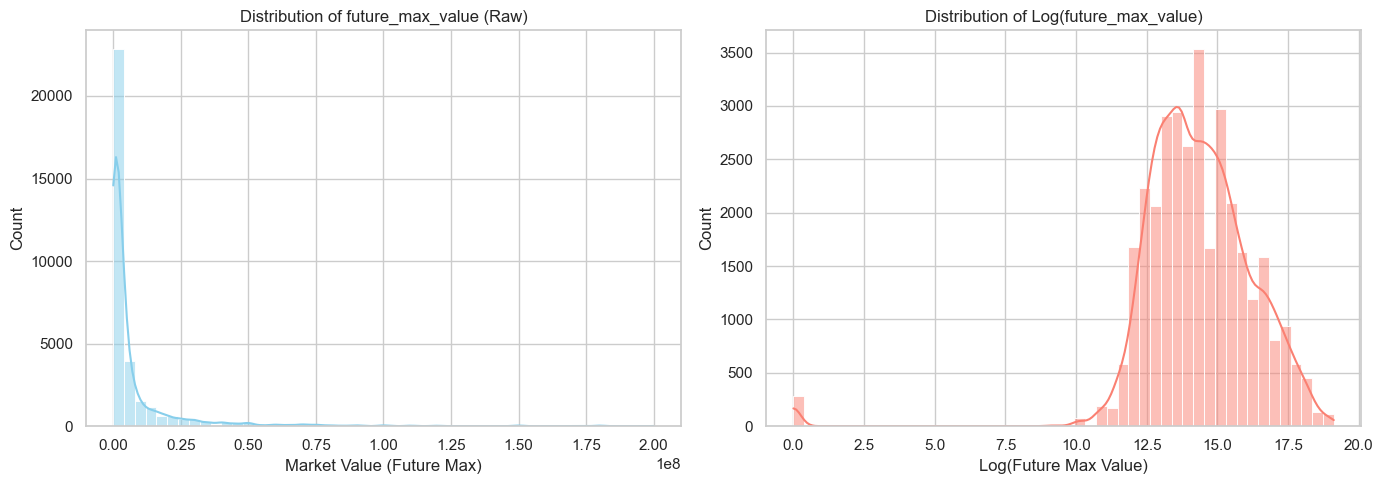

In [6]:
# הגדרת משתנה המטרה המדויק מהקובץ שלך
TARGET_COL = 'future_max_value'

# מסננים שורות שאין בהן שווי עתידי
df_clean_mv = df.dropna(subset=[TARGET_COL]).copy()

plt.figure(figsize=(14, 5))

# גרף 1: שווי שוק רגיל
plt.subplot(1, 2, 1)
sns.histplot(df_clean_mv[TARGET_COL], bins=50, kde=True, color='skyblue')
plt.title(f'Distribution of {TARGET_COL} (Raw)')
plt.xlabel('Market Value (Future Max)')
plt.ylabel('Count')

# גרף 2: שווי שוק לוגריתמי
plt.subplot(1, 2, 2)
# np.log1p עושה Log(1+x)
df_clean_mv['log_target'] = np.log1p(df_clean_mv[TARGET_COL])
sns.histplot(df_clean_mv['log_target'], bins=50, kde=True, color='salmon')
plt.title(f'Distribution of Log({TARGET_COL})')
plt.xlabel('Log(Future Max Value)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [12]:
# =====================================================================
# תא 6: רדאר איכות נתונים - זיהוי עמודות עם המון חסרים (NULL) או אפסים
# =====================================================================

total_rows = len(df)

# 1. חישוב אחוז הערכים החסרים (NULL / NaN) לכל עמודה
missing_pct = (df.isnull().sum() / total_rows) * 100

# 2. חישוב אחוז האפסים 
# נסנן רק עמודות מספריות כדי למנוע שגיאות על עמודות טקסט (כמו שם שחקן)
numeric_df = df.select_dtypes(include=[np.number])
zero_pct = (numeric_df == 0).sum() / total_rows * 100

# 3. איחוד הנתונים לטבלה אחת מסודרת
data_quality = pd.DataFrame({
    'Missing_Percentage (%)': missing_pct,
    'Zero_Percentage (%)': zero_pct
}).dropna(how='all') # מסיר עמודות טקסט שאין להן חישוב אפסים

# 4. סינון חכם: נציג רק עמודות "חשודות"
# למשל: מעל 40% נתונים חסרים, או מעל 85% ערכים שהם אפס
problematic_cols = data_quality[
    (data_quality['Missing_Percentage (%)'] > 5) | 
    (data_quality['Zero_Percentage (%)'] > 50)
].sort_values(by=['Zero_Percentage (%)', 'Missing_Percentage (%)'], ascending=[False, False])

print(f"Total rows in dataset: {total_rows}")
print(f"Found {len(problematic_cols)} potentially 'noisy' columns:")
display(problematic_cols.round(2)) # עיגול ל-2 ספרות אחרי הנקודה

Total rows in dataset: 45789
Found 44 potentially 'noisy' columns:


,Missing_Percentage (%),Zero_Percentage (%)
crossesNotClaimed,0.22,99.78
saves,0.22,99.74
penaltySave,1.87,98.12
savesCaught,1.87,98.12
savedShotsFromInsideTheBox,1.87,98.12
savedShotsFromOutsideTheBox,1.87,98.12
punches,1.87,98.11
highClaims,1.87,98.11
runsOut,1.87,98.11
savesParried,1.87,98.11


Top Positive Correlations (Features that INCREASE future value):


log_target                  1.000000
future_max_value            0.553079
mv_end                      0.490817
mv_start                    0.471034
expectedGoals               0.256620
expectedAssists             0.241300
totalContest                0.207497
goalsAssistsSum             0.205167
successfulDribbles          0.202831
outfielderBlocks            0.197120
shotsOnTarget               0.197094
accurateFinalThirdPasses    0.196599
goals                       0.188195
blockedShots                0.187447
totwAppearances             0.187192
Name: log_target, dtype: float64


Top Negative Correlations (Features that DECREASE future value):


league_tier     -0.427342
team_tier       -0.265397
team id         -0.188281
age_in_season   -0.161568
tm_id           -0.019801
Name: log_target, dtype: float64

C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\643336002.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features_to_plot.values, y=features_to_plot.index, palette='viridis')


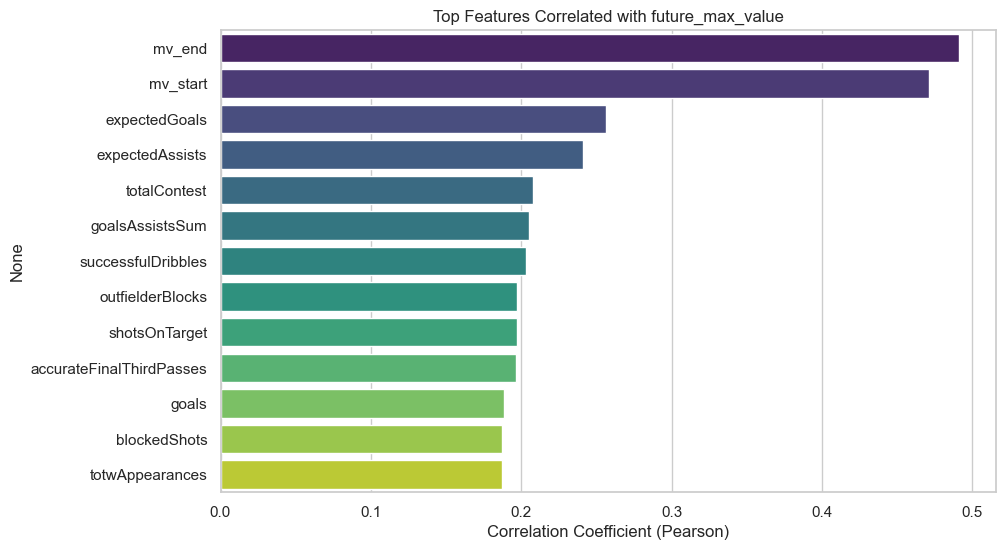

In [13]:
# בחירת עמודות מספריות בלבד
numeric_cols = df_clean_mv.select_dtypes(include=[np.number])

# חישוב קורלציה מול השווי הלוגריתמי העתידי
correlations = numeric_cols.corr()['log_target'].dropna()

top_positive = correlations.sort_values(ascending=False).head(15)
top_negative = correlations.sort_values(ascending=True).head(5)

print("Top Positive Correlations (Features that INCREASE future value):")
display(top_positive)

print("\nTop Negative Correlations (Features that DECREASE future value):")
display(top_negative)

# ציור גרף
features_to_plot = top_positive.drop(['log_target', TARGET_COL], errors='ignore')

plt.figure(figsize=(10, 6))
sns.barplot(x=features_to_plot.values, y=features_to_plot.index, palette='viridis')
plt.title(f'Top Features Correlated with {TARGET_COL}')
plt.xlabel('Correlation Coefficient (Pearson)')
plt.show()

C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\1024501222.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='league_tier', y='log_target', palette='Set2')
C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\1024501222.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='team_tier', y='log_target', palette='Set3')


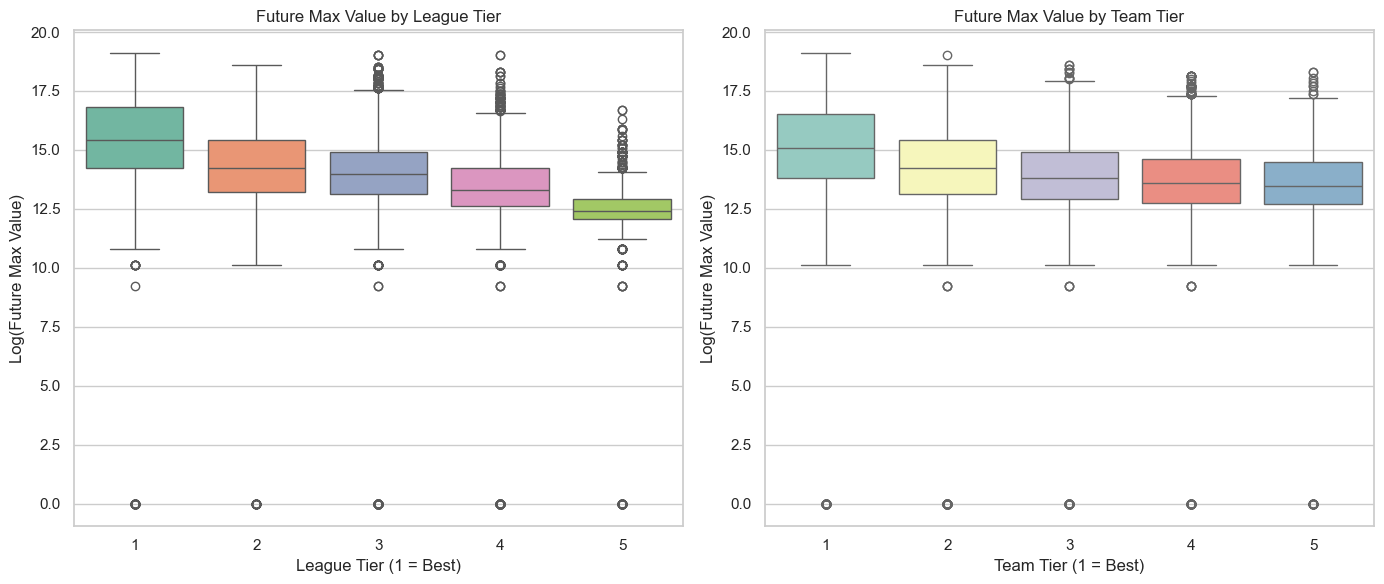

In [14]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean_mv, x='league_tier', y='log_target', palette='Set2')
plt.title('Future Max Value by League Tier')
plt.xlabel('League Tier (1 = Best)')
plt.ylabel('Log(Future Max Value)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean_mv, x='team_tier', y='log_target', palette='Set3')
plt.title('Future Max Value by Team Tier')
plt.xlabel('Team Tier (1 = Best)')
plt.ylabel('Log(Future Max Value)')

plt.tight_layout()
plt.show()

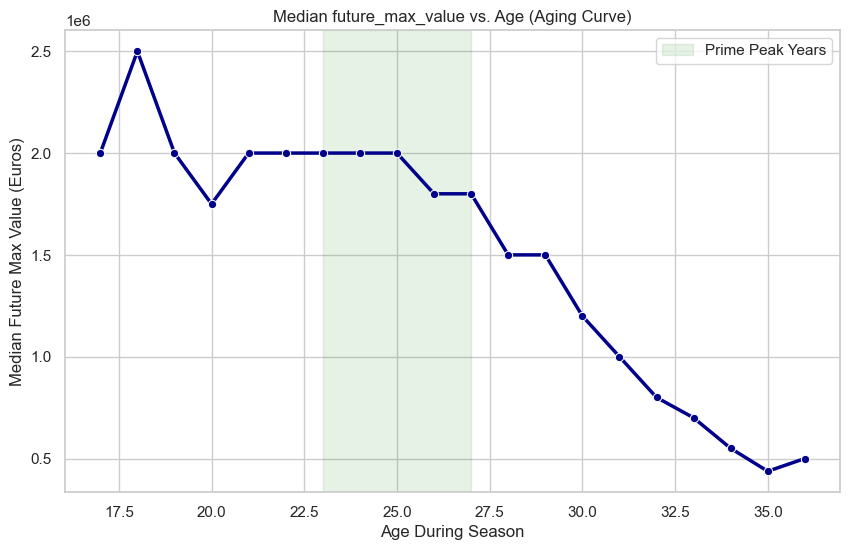

In [15]:
plt.figure(figsize=(10, 6))

age_median_value = df_clean_mv.groupby('age_in_season')[TARGET_COL].median().reset_index()
age_median_value = age_median_value[(age_median_value['age_in_season'] >= 17) & (age_median_value['age_in_season'] <= 36)]

sns.lineplot(data=age_median_value, x='age_in_season', y=TARGET_COL, marker='o', linewidth=2.5, color='darkblue')
plt.title(f'Median {TARGET_COL} vs. Age (Aging Curve)')
plt.xlabel('Age During Season')
plt.ylabel('Median Future Max Value (Euros)')

# הדגשת שנות השיא (Peak Years)
plt.axvspan(23, 27, color='green', alpha=0.1, label='Prime Peak Years')
plt.legend()
plt.show()

In [16]:
# יצירת מאפיינים חדשים זמניים בתוך ה-EDA
# נחשב כמה משחקים מלאים (90 דקות) השחקן שיחק
df_clean_mv['90s_played'] = df_clean_mv['minutesPlayed'] / 90.0

# מניעת חלוקה ב-0
df_clean_mv['goals_per_90'] = np.where(df_clean_mv['90s_played'] > 0, df_clean_mv['goals'] / df_clean_mv['90s_played'], 0)
df_clean_mv['assists_per_90'] = np.where(df_clean_mv['90s_played'] > 0, df_clean_mv['assists'] / df_clean_mv['90s_played'], 0)
df_clean_mv['goal_contributions_per_90'] = df_clean_mv['goals_per_90'] + df_clean_mv['assists_per_90']

# נבדוק את הקורלציה של הפיצ'רים החדשים לשווי הלוגריתמי העתידי
new_features = ['goals', 'goals_per_90', 'assists', 'assists_per_90', 'goal_contributions_per_90']

print("Correlation with Log(Future Max Value):")
display(df_clean_mv[new_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

Correlation with Log(Future Max Value):


log_target                   1.000000
goals                        0.188195
assists                      0.168445
goals_per_90                 0.086645
goal_contributions_per_90    0.073107
assists_per_90               0.023932
Name: log_target, dtype: float64

C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\2577744302.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='versatility_group', y='log_target', palette='Set2')


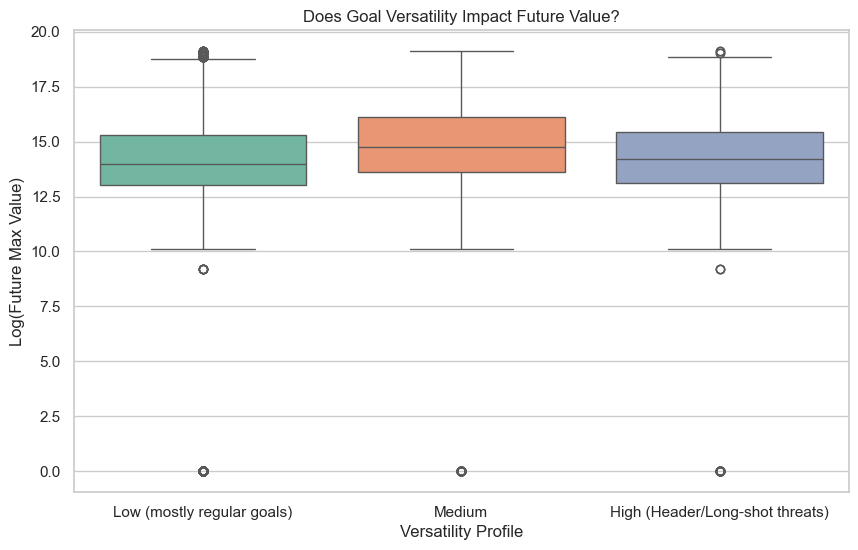

In [17]:
# מילוי אפסים בעמודות הרלוונטיות
cols_to_fill = ['headedGoals', 'goalsFromOutsideTheBox', 'penaltyGoals']
for col in cols_to_fill:
    if col in df_clean_mv.columns:
        df_clean_mv[col] = df_clean_mv[col].fillna(0)

# נחשב את ה"גיוון" - כמה מהשערים שלו לא היו שערים רגילים ברחבה?
df_clean_mv['special_goals_ratio'] = np.where(
    df_clean_mv['goals'] > 0, 
    (df_clean_mv['headedGoals'] + df_clean_mv['goalsFromOutsideTheBox']) / df_clean_mv['goals'], 
    0
)

# נצייר גרף שמראה אם שחקנים מגוונים יותר שווים יותר כסף
plt.figure(figsize=(10, 6))

# נחלק את השחקנים ל-3 קבוצות גיוון לשם הוויזואליזציה
df_clean_mv['versatility_group'] = pd.cut(
    df_clean_mv['special_goals_ratio'], 
    bins=[-1, 0.1, 0.4, 1.1], 
    labels=['Low (mostly regular goals)', 'Medium', 'High (Header/Long-shot threats)']
)

sns.boxplot(data=df_clean_mv, x='versatility_group', y='log_target', palette='Set2')
plt.title('Does Goal Versatility Impact Future Value?')
plt.xlabel('Versatility Profile')
plt.ylabel('Log(Future Max Value)')
plt.show()

Correlation with Log(Future Max Value):


log_target                     1.000000
penaltiesTaken                 0.084271
penaltyGoals                   0.082821
calculated_penalty_accuracy    0.070855
freeKickGoal                   0.045228
Name: log_target, dtype: float64

C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\1584635611.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='penalty_goals_group', y='log_target', palette='Blues')
C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\1584635611.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='free_kick_group', y='log_target', palette='Greens')


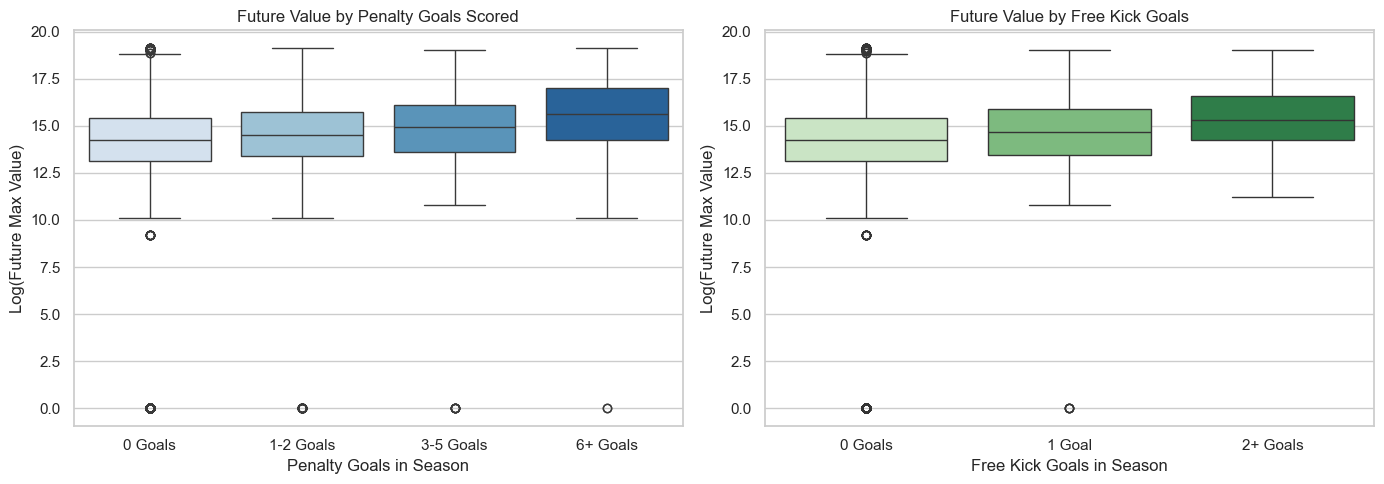

In [18]:
# =====================================================================
# תא 9: ניתוח מצבים נייחים - כמות כיבושים ואחוזי דיוק
# =====================================================================

# 1. טיפול באפסים - נמלא ב-0 את מי שאין לו נתון (כדי שנוכל לחשב)
cols_to_fill = ['penaltyGoals', 'penaltiesTaken', 'freeKickGoal']
for col in cols_to_fill:
    if col in df_clean_mv.columns:
        df_clean_mv[col] = df_clean_mv[col].fillna(0)

# 2. חישוב אחוז הדיוק בפנדלים (0 עד 100)
# שימוש ב-np.where כדי למנוע שגיאת חלוקה באפס למי שלא בעט מעולם
df_clean_mv['calculated_penalty_accuracy'] = np.where(
    df_clean_mv['penaltiesTaken'] > 0, 
    (df_clean_mv['penaltyGoals'] / df_clean_mv['penaltiesTaken']) * 100, 
    0
)

# 3. בדיקת הקורלציה של הנתונים האלו לשווי העתידי
set_piece_features = ['penaltyGoals', 'penaltiesTaken', 'calculated_penalty_accuracy', 'freeKickGoal']

print("Correlation with Log(Future Max Value):")
display(df_clean_mv[set_piece_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

# 4. ויזואליזציה מפוצלת: השפעת פנדלים ובעיטות חופשיות על השווי
plt.figure(figsize=(14, 5))

# --- גרף ימני: השפעת כמות שערי הפנדלים ---
plt.subplot(1, 2, 1)
# נקבץ את כמות הפנדלים לקבוצות כדי שהגרף יהיה קריא (0, 1-2, 3-5, 6+)
df_clean_mv['penalty_goals_group'] = pd.cut(
    df_clean_mv['penaltyGoals'], 
    bins=[-1, 0, 2, 5, 100], 
    labels=['0 Goals', '1-2 Goals', '3-5 Goals', '6+ Goals']
)
sns.boxplot(data=df_clean_mv, x='penalty_goals_group', y='log_target', palette='Blues')
plt.title('Future Value by Penalty Goals Scored')
plt.xlabel('Penalty Goals in Season')
plt.ylabel('Log(Future Max Value)')

# --- גרף שמאלי: השפעת בעיטות חופשיות ---
plt.subplot(1, 2, 2)
# נקבץ שערי בעיטות חופשיות (נדיר יותר מפנדלים)
df_clean_mv['free_kick_group'] = pd.cut(
    df_clean_mv['freeKickGoal'], 
    bins=[-1, 0, 1, 100], 
    labels=['0 Goals', '1 Goal', '2+ Goals']
)
sns.boxplot(data=df_clean_mv, x='free_kick_group', y='log_target', palette='Greens')
plt.title('Future Value by Free Kick Goals')
plt.xlabel('Free Kick Goals in Season')
plt.ylabel('Log(Future Max Value)')

plt.tight_layout()
plt.show()

Correlation with Log(Future Max Value) - Min 180 Mins Played:


log_target        1.000000
goals             0.190364
goals_per_90      0.180506
assists           0.168577
assists_per_90    0.125880
minutesPlayed     0.100005
Name: log_target, dtype: float64

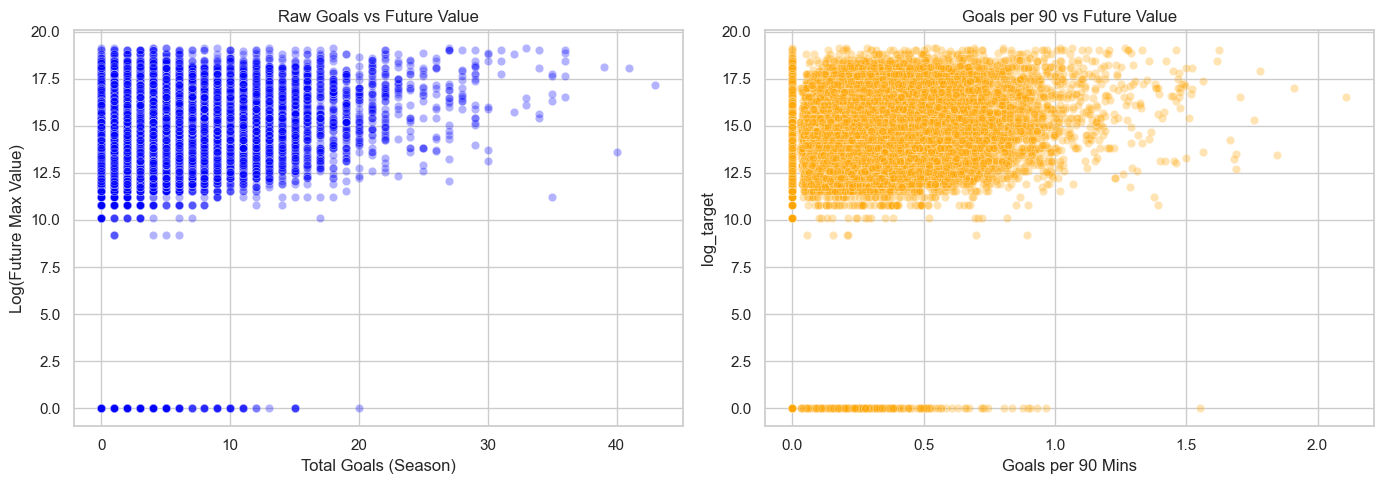

In [19]:
# =====================================================================
# תא 10: האם Per-90 באמת מנצח את המספרים הגולמיים (Raw Totals)?
# =====================================================================

# 1. חישוב מדדי Per 90 לחשובים ביותר
df_clean_mv['90s_played'] = df_clean_mv['minutesPlayed'] / 90.0
df_clean_mv['goals_per_90'] = np.where(df_clean_mv['90s_played'] > 0, df_clean_mv['goals'] / df_clean_mv['90s_played'], 0)
df_clean_mv['assists_per_90'] = np.where(df_clean_mv['90s_played'] > 0, df_clean_mv['assists'] / df_clean_mv['90s_played'], 0)

# ננקה שחקנים ששיחקו פחות מ-180 דקות (2 משחקים) כדי למנוע עיוותי "שחקני גביע"
df_filtered = df_clean_mv[df_clean_mv['minutesPlayed'] >= 180].copy()

# 2. השוואת הקורלציות מול שווי השוק העתידי
comparison_features = ['goals', 'goals_per_90', 'assists', 'assists_per_90', 'minutesPlayed']
print("Correlation with Log(Future Max Value) - Min 180 Mins Played:")
corr_comparison = df_filtered[comparison_features + ['log_target']].corr()['log_target'].sort_values(ascending=False)
display(corr_comparison)

# 3. ויזואליזציה של ההבדל (Goals vs Goals_p90)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_filtered, x='goals', y='log_target', alpha=0.3, color='blue')
plt.title('Raw Goals vs Future Value')
plt.xlabel('Total Goals (Season)')
plt.ylabel('Log(Future Max Value)')

plt.subplot(1, 2, 2)
# הגבלת ציר ה-X כדי לא לראות שחקנים חריגים עם נתון מופרך של 5 שערים ל-90 דקות
sns.scatterplot(data=df_filtered[df_filtered['goals_per_90'] < 2.5], x='goals_per_90', y='log_target', alpha=0.3, color='orange')
plt.title('Goals per 90 vs Future Value')
plt.xlabel('Goals per 90 Mins')

plt.tight_layout()
plt.show()

In [20]:
# =====================================================================
# תא 11: בדיקת הפיצ'רים הנגזרים (מי הכי שווה כסף?)
# =====================================================================

# 1. שערים ממשחק פתוח (מורידים פנדלים ובעיטות חופשיות)
df_clean_mv['penaltyGoals'] = df_clean_mv.get('penaltyGoals', 0).fillna(0)
df_clean_mv['freeKickGoal'] = df_clean_mv.get('freeKickGoal', 0).fillna(0)
df_clean_mv['open_play_goals'] = df_clean_mv['goals'] - df_clean_mv['penaltyGoals'] - df_clean_mv['freeKickGoal']

# 2. אחוז פתיחות בהרכב מתוך סך ההופעות
df_clean_mv['starts_rate'] = np.where(
    df_clean_mv['appearances'] > 0, 
    df_clean_mv['matchesStarted'] / df_clean_mv['appearances'], 
    0
)

# 3. אחוז שערים מתוך הרחבה (חלוץ מטרה אמיתי?)
df_clean_mv['goalsFromInsideTheBox'] = df_clean_mv.get('goalsFromInsideTheBox', 0).fillna(0)
df_clean_mv['inside_box_goal_share'] = np.where(
    df_clean_mv['goals'] > 0, 
    df_clean_mv['goalsFromInsideTheBox'] / df_clean_mv['goals'], 
    0
)

# 4. בדיקת קורלציה של כוכבי ההנדסה החדשים
best_derived = ['open_play_goals', 'goals', 'starts_rate', 'matchesStarted', 'inside_box_goal_share']
print("Correlation of New Derived Features vs Future Value:")
display(df_clean_mv[best_derived + ['log_target']].corr()['log_target'].sort_values(ascending=False))

Correlation of New Derived Features vs Future Value:


log_target               1.000000
open_play_goals          0.193017
goals                    0.188195
starts_rate              0.181609
matchesStarted           0.127125
inside_box_goal_share    0.116067
Name: log_target, dtype: float64

--- Age vs Age Squared Correlation ---


age_in_season   -0.161568
age_squared     -0.174203
log_target       1.000000
Name: log_target, dtype: float64

C:\Users\idoha\AppData\Local\Temp\ipykernel_36088\1743880108.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean_mv, x='primary_position', y='log_target', palette='Set3')


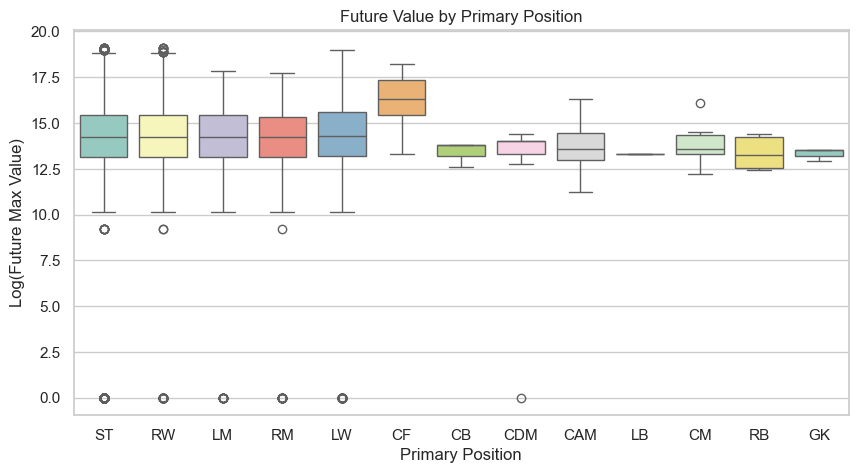

In [21]:
# =====================================================================
# תא 12: בדיקת השפעת הגיל בריבוע וחלוקת עמדות
# =====================================================================

# 1. גיל בריבוע (Age Squared) - עוזר למודלים ליניאריים להבין ירידה בכושר
df_clean_mv['age_squared'] = df_clean_mv['age_in_season'] ** 2

print("--- Age vs Age Squared Correlation ---")
display(df_clean_mv[['age_in_season', 'age_squared', 'log_target']].corr()['log_target'])

# 2. חילוץ העמדה הראשית (Primary Position)
# פיצול פסיקים ולקיחת האיבר הראשון (למשל מ-'F, M' ניקח רק 'F')
df_clean_mv['primary_position'] = df_clean_mv['player_positions'].astype(str).str.split(',').str[0].str.strip()

# ויזואליזציה של שווי לפי עמדה ראשית
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean_mv, x='primary_position', y='log_target', palette='Set3')
plt.title('Future Value by Primary Position')
plt.xlabel('Primary Position')
plt.ylabel('Log(Future Max Value)')
plt.show()

In [22]:
# =====================================================================
# תא 13: בדיקת יחסי מסירות ובעיטות (Shares) שהוצעו
# =====================================================================

# 1. אחוז הבעיטות מתוך הרחבה
df_clean_mv['totalShots'] = df_clean_mv.get('totalShots', 0).fillna(0)
df_clean_mv['shotsFromInsideTheBox'] = df_clean_mv.get('shotsFromInsideTheBox', 0).fillna(0)

df_clean_mv['inside_box_shot_share'] = np.where(
    df_clean_mv['totalShots'] > 0, 
    df_clean_mv['shotsFromInsideTheBox'] / df_clean_mv['totalShots'], 
    0
)

# 2. מעורבות בשליש ההתקפי (Final Third Share)
df_clean_mv['accurateOwnHalfPasses'] = df_clean_mv.get('accurateOwnHalfPasses', 0).fillna(0)
df_clean_mv['accurateOppositionHalfPasses'] = df_clean_mv.get('accurateOppositionHalfPasses', 0).fillna(0)
df_clean_mv['accurateFinalThirdPasses'] = df_clean_mv.get('accurateFinalThirdPasses', 0).fillna(0)

# סך המסירות שלו (בחצי שלו + בחצי היריב)
total_passes = df_clean_mv['accurateOwnHalfPasses'] + df_clean_mv['accurateOppositionHalfPasses']

df_clean_mv['final_third_share'] = np.where(
    total_passes > 0, 
    df_clean_mv['accurateFinalThirdPasses'] / total_passes, 
    0
)

print("--- Correlation of Shot & Pass Shares ---")
share_features = ['inside_box_shot_share', 'final_third_share']
display(df_clean_mv[share_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

--- Correlation of Shot & Pass Shares ---


log_target               1.000000
final_third_share        0.111578
inside_box_shot_share    0.040031
Name: log_target, dtype: float64

--- Modern Forward Score vs Goals ---


log_target              1.000000
modern_forward_score    0.232031
goals                   0.190364
goals_per_90            0.180506
Name: log_target, dtype: float64

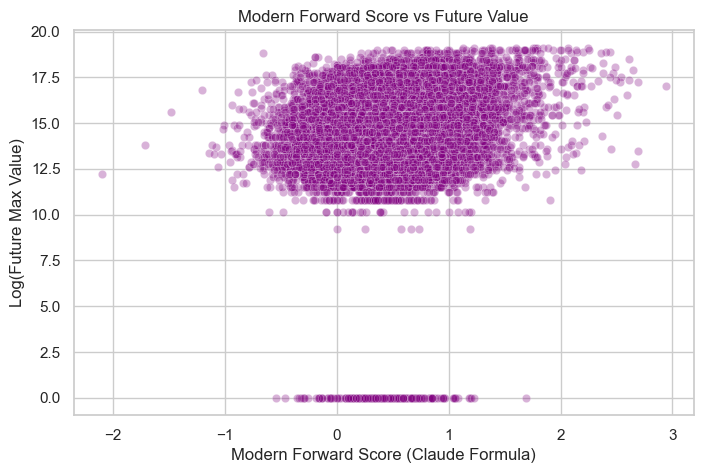

In [23]:
# =====================================================================
# תא 14: בדיקת "מדד החלוץ המודרני" (Composite Score)
# =====================================================================

# 1. חישוב Per 90 לכל המרכיבים בנוסחה (אם חסר נתון, נשים 0)
features_to_p90 = ['bigChancesCreated', 'possessionWonAttThird', 'successfulDribbles', 'dispossessed']
for f in features_to_p90:
    df_clean_mv[f] = df_clean_mv.get(f, 0).fillna(0)
    df_clean_mv[f'{f}_p90'] = np.where(df_clean_mv['90s_played'] > 0, df_clean_mv[f] / df_clean_mv['90s_played'], 0)

# 2. הנוסחה המדויקת של קלוד
df_clean_mv['modern_forward_score'] = (
    df_clean_mv['goals_per_90'] + 
    0.7 * df_clean_mv['assists_per_90'] + 
    0.5 * df_clean_mv['bigChancesCreated_p90'] + 
    0.3 * df_clean_mv['possessionWonAttThird_p90'] + 
    0.2 * df_clean_mv['successfulDribbles_p90'] - 
    0.3 * df_clean_mv['dispossessed_p90']
)

# 3. השוואת הקורלציה של המדד המשולב מול שערים גולמיים ו-Per90 רגיל
# נסנן שחקנים עם פחות מ-180 דקות כדי שהמדד יהיה יציב
df_test = df_clean_mv[df_clean_mv['minutesPlayed'] >= 180].copy()

comp_features = ['goals', 'goals_per_90', 'modern_forward_score']
print("--- Modern Forward Score vs Goals ---")
display(df_test[comp_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

# ויזואליזציה
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_test[df_test['modern_forward_score'] < 5], x='modern_forward_score', y='log_target', alpha=0.3, color='purple')
plt.title('Modern Forward Score vs Future Value')
plt.xlabel('Modern Forward Score (Claude Formula)')
plt.ylabel('Log(Future Max Value)')
plt.show()

In [24]:
# =====================================================================
# תא 15: ניקוי ה"פולשים" - השארת שחקנים עם אוריינטציה התקפית בלבד
# =====================================================================

# רשימת העמדות המוגדרות כהתקפיות או כנף
attacking_roles = ['ST', 'CF', 'RW', 'LW', 'RM', 'LM', 'CAM', 'AM']

# פונקציה שבודקת אם לפחות עמדה התקפית אחת מופיעה ברשימת העמדות של השחקן
def has_attacking_role(positions_str):
    if pd.isna(positions_str):
        return False
    # פיצול המחרוזת לפי פסיק וניקוי רווחים
    player_roles = [role.strip() for role in str(positions_str).split(',')]
    return any(role in attacking_roles for role in player_roles)

# הפעלת הסינון על הדאטא
df_clean_mv['is_attacker'] = df_clean_mv['player_positions'].apply(has_attacking_role)
df_attackers = df_clean_mv[df_clean_mv['is_attacker'] == True].copy()

print(f"Rows before filter: {len(df_clean_mv)}")
print(f"Rows after strict attacker filter: {len(df_attackers)}")

Rows before filter: 33454
Rows after strict attacker filter: 33424


In [25]:
# =====================================================================
# תא 16: הנדסת מאפיינים - התאמות גיל, ליגה, ואיכות בעיטה
# =====================================================================

# 1. Age Penalty (קנס גיל במקום גיל בריבוע) - מתמקד רק בנפילה אחרי גיל 25
df_attackers['age_penalty'] = np.where(df_attackers['age_in_season'] >= 25, 
                                       (df_attackers['age_in_season'] - 25)**2, 0)

# 2. League-Adjusted Goal Contributions (מעורבות בשערים מותאמת קושי ליגה)
# מניח שחישבת כבר goals_per_90 ו-assists_per_90 בתאים קודמים
df_attackers['ga_vs_league'] = (df_attackers['goals_per_90'] + df_attackers['assists_per_90']) * (6 - df_attackers['league_tier'])

# 3. תחליף xG (Shot Quality Proxy) לפתרון בעיית ה-NULLs
df_attackers['shotsFromInsideTheBox'] = df_attackers.get('shotsFromInsideTheBox', 0).fillna(0)
df_attackers['shotsFromOutsideTheBox'] = df_attackers.get('shotsFromOutsideTheBox', 0).fillna(0)
df_attackers['shotsOnTarget'] = df_attackers.get('shotsOnTarget', 0).fillna(0)

# חישוב Per 90 לבעיטות
df_attackers['shots_in_box_p90'] = np.where(df_attackers['90s_played'] > 0, df_attackers['shotsFromInsideTheBox'] / df_attackers['90s_played'], 0)
df_attackers['shots_out_p90'] = np.where(df_attackers['90s_played'] > 0, df_attackers['shotsFromOutsideTheBox'] / df_attackers['90s_played'], 0)
df_attackers['sot_p90'] = np.where(df_attackers['90s_played'] > 0, df_attackers['shotsOnTarget'] / df_attackers['90s_played'], 0)

# הנוסחה לייצור ה-Proxy
df_attackers['shot_quality_proxy'] = (0.12 * df_attackers['shots_in_box_p90']) + (0.04 * df_attackers['shots_out_p90']) + (0.08 * df_attackers['sot_p90'])

# 4. בדיקת קורלציות מול שווי עתידי ומול דלתא
df_attackers['log_mv_start'] = np.log1p(df_attackers['mv_start'])
df_attackers['log_delta'] = df_attackers['log_target'] - df_attackers['log_mv_start']

math_features = ['age_penalty', 'ga_vs_league', 'shot_quality_proxy', 'goals_per_90']
print("--- Correlation with Log(Future Max Value) ---")
display(df_attackers[math_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

print("\n--- Correlation with Log Delta (Growth Potential) ---")
display(df_attackers[math_features + ['log_delta']].corr()['log_delta'].sort_values(ascending=False))

--- Correlation with Log(Future Max Value) ---


log_target            1.000000
ga_vs_league          0.154668
goals_per_90          0.086496
shot_quality_proxy    0.054215
age_penalty          -0.210467
Name: log_target, dtype: float64


--- Correlation with Log Delta (Growth Potential) ---


log_delta             1.000000
shot_quality_proxy    0.017843
goals_per_90          0.015513
ga_vs_league          0.012309
age_penalty          -0.301121
Name: log_delta, dtype: float64

In [28]:
# =====================================================================
# תא 17: חישובי סביבה - Z-Scores ואחוזי שליטה בקבוצה (מתוקן)
# =====================================================================

# 1. Z-Scores: ציון תקן לכל שחקן ביחס ל*דרג הליגה* שלו באותה עונה (במקום הליגה הספציפית)
def calculate_zscore(x):
    return (x - x.mean()) / (x.std() + 1e-6)

df_attackers['rating_tier_z'] = df_attackers.groupby(['league_tier', '_season_year'])['rating'].transform(calculate_zscore)
df_attackers['goals_tier_z'] = df_attackers.groupby(['league_tier', '_season_year'])['goals'].transform(calculate_zscore)

# 2. Rating Residuals (עד כמה הוא טוב יותר מהממוצע של קבוצות ברמה שלו?)
tier_mean_rating = df_attackers.groupby(['league_tier', 'team_tier'])['rating'].transform('mean')
df_attackers['rating_residual'] = df_attackers['rating'] - tier_mean_rating

# 3. תלות קבוצתית (Goal Dependency)
# נשתמש ב-'team id' המספרי במקום בשם הקבוצה שמחקנו
if 'team id' in df_attackers.columns:
    team_total_goals = df_attackers.groupby(['team id', '_season_year'])['goals'].transform('sum')
    # איזה אחוז מסך השערים שייך לשחקן הזה?
    df_attackers['team_goal_share'] = np.where(team_total_goals > 0, df_attackers['goals'] / team_total_goals, 0)
else:
    df_attackers['team_goal_share'] = 0
    print("Warning: 'team id' not found.")

env_features = ['rating_tier_z', 'goals_tier_z', 'rating_residual', 'team_goal_share']
print("--- Correlation of Environmental Features ---")
display(df_attackers[env_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

--- Correlation of Environmental Features ---


log_target         1.000000
goals_tier_z       0.221896
rating_tier_z      0.142385
rating_residual    0.112343
team_goal_share    0.031345
Name: log_target, dtype: float64

In [31]:
# =====================================================================
# תא 18: מאפייני היסטוריה (מתוקן) + מומנטום ושיא קריירה
# =====================================================================

# 1. ניקוי שנת העונה חסין לשגיאות (טיפול ב-'17/18' מול '2017/2018')
extracted_year = df_attackers['_season_year'].astype(str).str.extract(r'^(\d+)')[0].astype(int)
df_attackers['season_start_year'] = np.where(extracted_year < 100, extracted_year + 2000, extracted_year)

# 2. מיון כרונולוגי לפי שחקן
df_sorted = df_attackers.sort_values(by=['tm_id', 'season_start_year']).copy()

# 3. פיצ'רים היסטוריים ומומנטום
shifted_log_mv = df_sorted.groupby('tm_id')['log_mv_start'].shift(1)
df_sorted['log_mv_prev'] = shifted_log_mv

df_sorted['goals_p90_prev'] = df_sorted.groupby('tm_id')['goals_per_90'].shift(1)
df_sorted['scoring_momentum'] = df_sorted['goals_per_90'] - df_sorted['goals_p90_prev']

# 4. [חדש מקלוד] מאפייני "בגרות ושיאים" מתוך ההיסטוריה
df_sorted['n_prior_seasons'] = df_sorted.groupby('tm_id').cumcount()
# שיא שווי השוק עד לשנה שעברה (כדי לא לכלול את ההווה)
df_sorted['career_mv_peak_prev'] = shifted_log_mv.groupby(df_sorted['tm_id']).cummax()
# שיא אישי של יעילות הבקעה עד כה
df_sorted['max_career_goals_p90_prev'] = df_sorted['goals_p90_prev'].groupby(df_sorted['tm_id']).cummax()

# סינון לבדיקה
df_history = df_sorted.dropna(subset=['log_mv_prev']).copy()

history_features = ['log_mv_start', 'log_mv_prev', 'career_mv_peak_prev', 'scoring_momentum', 'n_prior_seasons']
print(f"--- Correlation on Players with History (N={len(df_history)}) ---")
display(df_history[history_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

--- Correlation on Players with History (N=25106) ---


log_target             1.000000
log_mv_start           0.709577
log_mv_prev            0.603900
career_mv_peak_prev    0.546305
n_prior_seasons        0.230476
scoring_momentum       0.009471
Name: log_target, dtype: float64

--- Correlation of Final Claude Ideas ---


log_target            1.000000
minutes_share         0.196958
goals_p90_clipped     0.155240
rating_x_minutes      0.131495
goals_per_90          0.086496
defensive_workrate   -0.007729
Name: log_target, dtype: float64

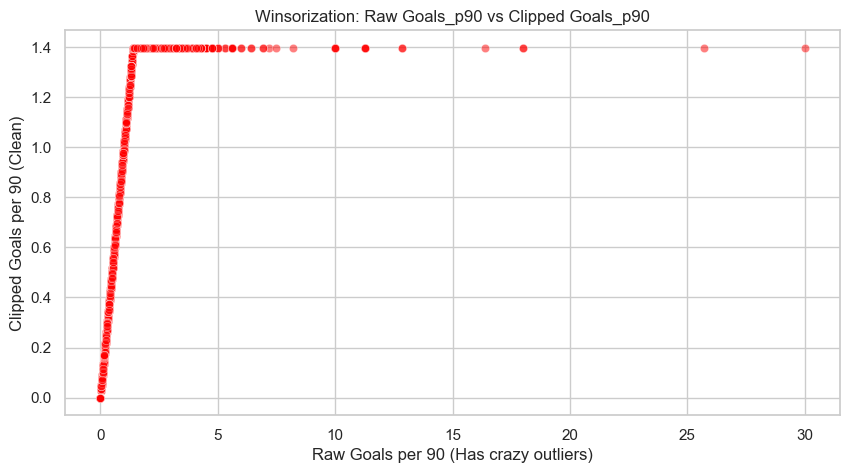

In [32]:
# =====================================================================
# תא 19: איכות מצטברת, עבודה שחורה, וקיטום רעשי ה-Per 90
# =====================================================================

# 1. Rating × Minutes (איכות × עמידות)
df_attackers['rating_x_minutes'] = df_attackers['rating'] * df_attackers['minutesPlayed']

# 2. Squad Role (איזה אחוז מהדקות האפשריות הוא שיחק?)
df_attackers['minutes_share'] = np.where(
    df_attackers['appearances'] > 0, 
    df_attackers['minutesPlayed'] / (df_attackers['appearances'] * 90.0), 
    0
)

# 3. עבודה הגנתית של חלוצים (Tackles+Interceptions / Touches)
# מילוי אפסים כדי למנוע שגיאות
for col in ['tackles', 'interceptions', 'ballRecovery', 'touches']:
    df_attackers[col] = df_attackers.get(col, 0).fillna(0)

defensive_actions = df_attackers['tackles'] + df_attackers['interceptions'] + df_attackers['ballRecovery']
df_attackers['defensive_workrate'] = np.where(df_attackers['touches'] > 0, defensive_actions / df_attackers['touches'], 0)

# 4. Winsorizing (קיטום ה-Per 90 לאחוזון ה-99 כדי להרוג חריגים סטטיסטיים)
# זה הופך את ה-goals_per_90 להרבה יותר חזק
p99_goals = df_attackers['goals_per_90'].quantile(0.99)
df_attackers['goals_p90_clipped'] = df_attackers['goals_per_90'].clip(upper=p99_goals)

# קורלציות לכולם
new_features = ['rating_x_minutes', 'minutes_share', 'defensive_workrate', 'goals_p90_clipped', 'goals_per_90']
print("--- Correlation of Final Claude Ideas ---")
display(df_attackers[new_features + ['log_target']].corr()['log_target'].sort_values(ascending=False))

# ויזואליזציה של למה הקיטום (Clipping) חובה
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_attackers, x='goals_per_90', y='goals_p90_clipped', alpha=0.5, color='red')
plt.title('Winsorization: Raw Goals_p90 vs Clipped Goals_p90')
plt.xlabel('Raw Goals per 90 (Has crazy outliers)')
plt.ylabel('Clipped Goals per 90 (Clean)')
plt.show()

In [36]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 8.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 10.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.2 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.1/36.6 MB 11.8 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/36.6 MB 11.4 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/36.6 MB 11.3 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/36.6 MB 11.3 MB/s eta 0:00:03
   ------------- -------------------------- 12.1/36.6 MB 11.3 MB/s eta 0:00:03
   --------------- ------------------------ 14.4/36.6 MB 11.3 MB/s eta 0:00:02
   --------

In [37]:
# =====================================================================
# תא 20: מנוע קורלציית שאריות (Residual R) - המבחן האולטימטיבי
# =====================================================================
from sklearn.linear_model import LinearRegression

# מסננים רק שחקנים שיש להם גם שווי התחלתי וגם שווי מטרה
df_resid = df_attackers.dropna(subset=['log_mv_start', 'log_target']).copy()

# 1. בניית מודל בסיס שמשתמש *רק* בשווי הנוכחי (mv_start)
X_base = df_resid[['log_mv_start']]
y_true = df_resid['log_target']

baseline_model = LinearRegression()
baseline_model.fit(X_base, y_true)
df_resid['predicted_from_start'] = baseline_model.predict(X_base)

# 2. חישוב ה"שארית" (Residual) - כמה השחקן התפתח מעבר למה שהשווי הנוכחי שלו ניבא?
df_resid['target_residual'] = df_resid['log_target'] - df_resid['predicted_from_start']

# פונקציית עזר לבדיקת פיצ'רים מול השארית
def check_residual_corr(features_list):
    results = []
    for f in features_list:
        if f in df_resid.columns:
            # מתאם סולו מול מתאם שארית
            solo_r = df_resid[f].corr(df_resid['log_target'])
            resid_r = df_resid[f].corr(df_resid['target_residual'])
            results.append({'Feature': f, 'Solo R': solo_r, 'Residual R': resid_r})
    
    res_df = pd.DataFrame(results).sort_values(by='Residual R', ascending=False)
    display(res_df.round(3))
    return res_df

print("Baseline setup complete. We will use `check_residual_corr` in the next cells.")

Baseline setup complete. We will use `check_residual_corr` in the next cells.


In [38]:
# =====================================================================
# תא 21: הנדסת דגלי זהב (Interaction Flags)
# =====================================================================

# 1. Young Top Club / League (ההייפ סביב צעירים)
df_resid['young_top_club'] = ((df_resid['age_in_season'] <= 21) & (df_resid['team_tier'] <= 2)).astype(int)
df_resid['young_top_league'] = ((df_resid['age_in_season'] <= 21) & (df_resid['league_tier'] <= 2)).astype(int)

# 2. Breakout Flag (פריצת דרך לגיל צעיר)
df_resid['breakout_flag'] = ((df_resid['goals_per_90'] > 0.4) & (df_resid['age_in_season'] <= 22)).astype(int)

# 3. Reliable Scorer (סקורר אמין - גם כובש וגם פותח קבוע)
if 'starts_rate' not in df_resid.columns:
    df_resid['starts_rate'] = np.where(df_resid['appearances'] > 0, df_resid['matchesStarted'] / df_resid['appearances'], 0)
df_resid['reliable_scorer'] = df_resid['goals_per_90'] * df_resid['starts_rate']

# 4. Starter x League (שחקן הרכב בליגה חזקה מול חלשה)
# נניח ש-league_tier הוא 1-5, נהפוך אותו לציון (5 זה הכי טוב, 1 זה הכי גרוע)
league_score_inv = 6 - df_resid['league_tier'] 
df_resid['starter_x_league'] = df_resid['starts_rate'] * league_score_inv

# בדיקת המשתנים החדשים במנוע השאריות שלנו!
new_flags = ['young_top_club', 'young_top_league', 'breakout_flag', 'reliable_scorer', 'starter_x_league']
print("--- Evaluating Interaction Flags (Residual Correlation) ---")
flags_results = check_residual_corr(new_flags)

--- Evaluating Interaction Flags (Residual Correlation) ---


,Feature,Solo R,Residual R
0,young_top_club,0.103,0.221
1,young_top_league,0.152,0.194
2,breakout_flag,0.097,0.140
4,starter_x_league,0.355,0.071
3,reliable_scorer,0.212,0.060


In [39]:
# =====================================================================
# תא 22: שערים מנורמלים - Bayesian Shrinkage (The Smart Per-90)
# =====================================================================

# 1. מציאת ה"Prior" (הממוצע העולמי)
global_goals_p90 = df_resid['goals'].sum() / df_resid['90s_played'].sum()

# 2. משקל ה-Prior: נקבע ל-10 משחקים (900 דקות). 
# כלומר, לפני ששחקן שיחק 900 דקות, אנחנו קצת סקפטיים לגבי התוצאות שלו.
prior_90s = 10.0 
prior_goals = prior_90s * global_goals_p90

# 3. הנוסחה הבייסיאנית (Shrunk P90)
df_resid['goals_p90_shrunk'] = (df_resid['goals'] + prior_goals) / (df_resid['90s_played'] + prior_90s)
df_resid['assists_p90_shrunk'] = (df_resid['assists'] + (prior_90s * (df_resid['assists'].sum() / df_resid['90s_played'].sum()))) / (df_resid['90s_played'] + prior_90s)

# 4. השוואה: האם ה-Shrunk באמת מנצח את ה-Per 90 הרגיל בשאריות?
shrink_features = ['goals', 'goals_per_90', 'goals_p90_shrunk', 'assists_p90_shrunk']
print("--- Evaluating Bayesian Shrinkage ---")
shrink_results = check_residual_corr(shrink_features)

--- Evaluating Bayesian Shrinkage ---


,Feature,Solo R,Residual R
2,goals_p90_shrunk,0.171,0.079
0,goals,0.185,0.070
3,assists_p90_shrunk,0.129,0.051
1,goals_per_90,0.088,0.037


In [40]:
# =====================================================================
# תא 23: הקשר קבוצתי רציף וקומפוזיציות מתקדמות
# =====================================================================

# 1. Log Team Mean MV (ציון כוח רציף לקבוצה מתוך שווי השחקנים)
if 'team id' in df_resid.columns:
    df_resid['team_mean_mv'] = df_resid.groupby(['team id', '_season_year'])['mv_start'].transform('mean')
    df_resid['log_team_mean_mv'] = np.log1p(df_resid['team_mean_mv'])
else:
    print("Warning: team id missing, skipping team_mean_mv")

# 2. Progression P90 (מדד חלופי להובלת כדור - משלב מסירות ודריבלים)
# ממלאים אפסים למניעת שגיאות
for col in ['accurateFinalThirdPasses', 'successfulDribbles', 'keyPasses']:
    df_resid[col] = df_resid.get(col, 0).fillna(0)
    df_resid[f'{col}_p90'] = np.where(df_resid['90s_played'] > 0, df_resid[col] / df_resid['90s_played'], 0)

df_resid['progression_p90'] = df_resid['accurateFinalThirdPasses_p90'] + df_resid['successfulDribbles_p90'] + df_resid['keyPasses_p90']

# בדיקה מול השאריות
adv_features = ['log_team_mean_mv', 'progression_p90']
print("--- Evaluating Advanced Team & Composite Features ---")
adv_results = check_residual_corr(adv_features)

--- Evaluating Advanced Team & Composite Features ---


,Feature,Solo R,Residual R
0,log_team_mean_mv,0.601,0.155
1,progression_p90,0.124,0.051


In [41]:
# =====================================================================
# תא 24: "מבחן הסקאוט" - גבולות בטוחים ל-mv_end ומומנטום שוק
# =====================================================================

# המרת תאריכים לפורמט Datetime חוקי
df_resid['mv_start_date'] = pd.to_datetime(df_resid.get('mv_start_date'), errors='coerce')
df_resid['mv_end_date'] = pd.to_datetime(df_resid.get('mv_end_date'), errors='coerce')

# 1. פונקציה לקביעת "תאריך החיתוך" המותר לפי סוג הליגה
def get_safe_boundary(season_str):
    season_str = str(season_str)
    if '/' in season_str:
        # ליגה אירופית מפוצלת (למשל 21/22) -> נגמרת בקיץ. ניקח את 31 ביולי כגבול הבטוח.
        year_end = season_str.split('/')[1]
        # טיפול ב-18 מול 2018
        year = int(year_end) + 2000 if len(year_end) == 2 else int(year_end)
        return pd.Timestamp(f'{year}-07-31')
    else:
        # ליגה קלנדרית (למשל 2022) -> מסתיימת בחורף. נתיר עד 31 בינואר של השנה הבאה.
        year = int(season_str[:4])
        return pd.Timestamp(f'{year + 1}-01-31')

# הפעלת הפונקציה ליצירת עמודת גבול בטוח
df_resid['safe_boundary_date'] = df_resid['_season_year'].apply(get_safe_boundary)

# 2. יצירת mv_end_safe: ניקח את שווי סוף העונה רק אם הוא קרה לפני הגבול שלנו!
df_resid['mv_end_safe'] = np.where(df_resid['mv_end_date'] <= df_resid['safe_boundary_date'], 
                                   df_resid['mv_end'], np.nan)
df_resid['log_mv_end_safe'] = np.log1p(df_resid['mv_end_safe'])

# 3. הנדסת פיצ'רים של מומנטום שוק (הצעות קלוד)
df_resid['log_mv_change_season'] = df_resid['log_mv_end_safe'] - df_resid['log_mv_start']
df_resid['mv_surge_flag'] = (df_resid['mv_end_safe'] > (df_resid['mv_start'] * 1.25)).astype(int) # זינוק של 25%

market_features = ['log_mv_end_safe', 'log_mv_change_season', 'mv_surge_flag']
print("--- Market Momentum Features (Residual R) ---")
display(check_residual_corr(market_features))

--- Market Momentum Features (Residual R) ---


,Feature,Solo R,Residual R
1,log_mv_change_season,0.185,0.481
2,mv_surge_flag,0.066,0.301
0,log_mv_end_safe,0.763,0.250


,Feature,Solo R,Residual R
1,log_mv_change_season,0.184526,0.480990
2,mv_surge_flag,0.066267,0.301432
0,log_mv_end_safe,0.763307,0.249545


In [42]:
# =====================================================================
# תא 25: סימולציית היסטוריה - מה מנבא טוב יותר, ממוצע או שיא?
# =====================================================================

# מיון כרונולוגי כדי שההיסטוריה תחושב נכון
df_sorted = df_resid.sort_values(by=['tm_id', 'safe_boundary_date']).copy()

# פונקציית עזר לחישוב נתונים היסטוריים (ללא העונה הנוכחית - Shift)
def get_historical_agg(df, col, agg_type):
    if agg_type == 'mean':
        return df.groupby('tm_id')[col].expanding().mean().reset_index(level=0, drop=True).shift(1)
    elif agg_type == 'max':
        return df.groupby('tm_id')[col].expanding().max().reset_index(level=0, drop=True).shift(1)
    elif agg_type == 'std':
        return df.groupby('tm_id')[col].expanding().std().reset_index(level=0, drop=True).shift(1)

# נבדוק על ציון SofaScore ועל שערים ל-90 דקות
df_sorted['hist_rating_mean'] = get_historical_agg(df_sorted, 'rating', 'mean')
df_sorted['hist_rating_max'] = get_historical_agg(df_sorted, 'rating', 'max')
df_sorted['hist_rating_std'] = get_historical_agg(df_sorted, 'rating', 'std')

df_sorted['hist_goals_p90_mean'] = get_historical_agg(df_sorted, 'goals_per_90', 'mean')

# מסננים לבדיקה רק שחקנים שיש להם היסטוריה מחושבת
df_hist_test = df_sorted.dropna(subset=['hist_rating_mean']).copy()

hist_features = ['hist_rating_mean', 'hist_rating_max', 'hist_rating_std', 'hist_goals_p90_mean']

print("--- Historical Aggregates Validation (Residual R) ---")
results = []
for f in hist_features:
    solo_r = df_hist_test[f].corr(df_hist_test['log_target'])
    resid_r = df_hist_test[f].corr(df_hist_test['target_residual'])
    results.append({'Feature': f, 'Solo R': solo_r, 'Residual R': resid_r})

display(pd.DataFrame(results).sort_values(by='Residual R', ascending=False).round(3))

--- Historical Aggregates Validation (Residual R) ---


,Feature,Solo R,Residual R
2,hist_rating_std,0.049,0.057
3,hist_goals_p90_mean,0.071,-0.011
1,hist_rating_max,0.152,-0.047
0,hist_rating_mean,0.075,-0.063


In [43]:
# =====================================================================
# תא 26: מומנטום ביצועים - Delta vs Mean
# =====================================================================

# 1. Delta: בכמה הציון של העונה הנוכחית גבוה/נמוך מהממוצע ההיסטורי שלו?
df_hist_test['delta_rating_vs_mean'] = df_hist_test['rating'] - df_hist_test['hist_rating_mean']

# 2. Delta: האם הוא מבקיע העונה יותר מהממוצע של עצמו?
df_hist_test['delta_goals_p90_vs_mean'] = df_hist_test['goals_per_90'] - df_hist_test['hist_goals_p90_mean']

delta_features = ['delta_rating_vs_mean', 'delta_goals_p90_vs_mean']

print("--- Player Momentum (Delta vs Mean) Validation ---")
results_delta = []
for f in delta_features:
    solo_r = df_hist_test[f].corr(df_hist_test['log_target'])
    resid_r = df_hist_test[f].corr(df_hist_test['target_residual'])
    results_delta.append({'Feature': f, 'Solo R': solo_r, 'Residual R': resid_r})

display(pd.DataFrame(results_delta).sort_values(by='Residual R', ascending=False).round(3))

--- Player Momentum (Delta vs Mean) Validation ---


,Feature,Solo R,Residual R
0,delta_rating_vs_mean,0.045,0.052
1,delta_goals_p90_vs_mean,0.023,0.040
